In [85]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [86]:
sentinel_data = pd.read_csv("Sentinel_5p_data.csv")
sentinel_data.head()

,Unnamed: 0,time,absorbing_aerosol_index,cloud_fraction,cloud_top_pressure,cloud_top_height,cloud_base_pressure,cloud_base_height,cloud_optical_depth,NO2_column_number_density,tropospheric_NO2_column_number_density,stratospheric_NO2_column_number_density,NO2_slant_column_number_density,tropopause_pressure,O3_column_number_density,O3_effective_temperature,CO_column_number_density,H2O_column_number_density
0,0,2018-07-04 00:00:00+03:00,-0.621235,NaN,NaN,NaN,NaN,NaN,NaN,0.000077,NaN,0.000062,0.000203,19219.670,NaN,NaN,NaN,NaN
1,1,2018-07-05 00:00:00+03:00,-0.659180,NaN,NaN,NaN,NaN,NaN,NaN,0.000072,0.000011,0.000065,0.000146,19219.450,NaN,NaN,0.027964,1824.4277
2,2,2018-07-06 00:00:00+03:00,-1.010234,NaN,NaN,NaN,NaN,NaN,NaN,0.000079,0.000010,0.000067,0.000198,19218.373,NaN,NaN,0.029050,1257.0642
3,3,2018-07-07 00:00:00+03:00,-1.175477,NaN,NaN,NaN,NaN,NaN,NaN,0.000083,0.000017,0.000069,0.000194,19223.537,NaN,NaN,0.028928,1455.8580
4,4,2018-07-08 00:00:00+03:00,-1.260407,NaN,NaN,NaN,NaN,NaN,NaN,0.000077,0.000006,0.000073,0.000199,19230.297,NaN,NaN,0.028053,1655.6798


In [87]:
sentinel_data = sentinel_data.drop(columns=['Unnamed: 0'])
sentinel_data['time'] = pd.to_datetime(sentinel_data['time'], utc=True)

sentinel_data = sentinel_data.set_index('time')
sentinel_data = sentinel_data.sort_index()

# Praleistų reikšmių apžvalga

In [88]:
print(sentinel_data.isnull().sum())

absorbing_aerosol_index                      37
cloud_fraction                              211
cloud_top_pressure                          316
cloud_top_height                            317
cloud_base_pressure                         316
cloud_base_height                           317
cloud_optical_depth                         317
NO2_column_number_density                   195
tropospheric_NO2_column_number_density     1229
stratospheric_NO2_column_number_density     195
NO2_slant_column_number_density             195
tropopause_pressure                         195
O3_column_number_density                    121
O3_effective_temperature                    121
CO_column_number_density                    515
H2O_column_number_density                   339
dtype: int64


In [89]:
missing_percent = sentinel_data.isnull().mean() * 100
print(missing_percent)

absorbing_aerosol_index                     1.314854
cloud_fraction                              7.498223
cloud_top_pressure                         11.229566
cloud_top_height                           11.265103
cloud_base_pressure                        11.229566
cloud_base_height                          11.265103
cloud_optical_depth                        11.265103
NO2_column_number_density                   6.929638
tropospheric_NO2_column_number_density     43.674485
stratospheric_NO2_column_number_density     6.929638
NO2_slant_column_number_density             6.929638
tropopause_pressure                         6.929638
O3_column_number_density                    4.299929
O3_effective_temperature                    4.299929
CO_column_number_density                   18.301350
H2O_column_number_density                  12.046908
dtype: float64


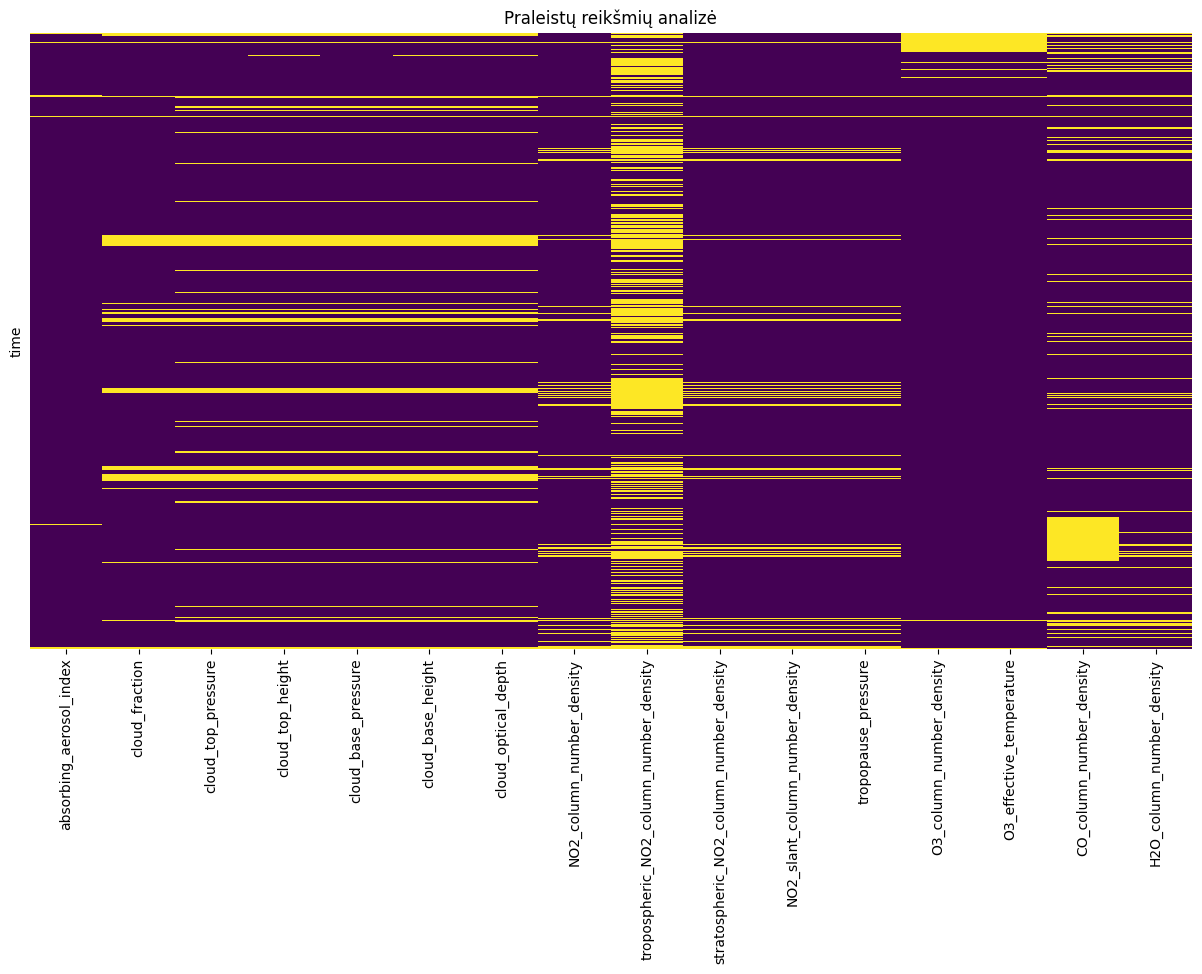

In [90]:
plt.figure(figsize=(15, 8))
sns.heatmap(sentinel_data.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Praleistų reikšmių analizė')
plt.show()

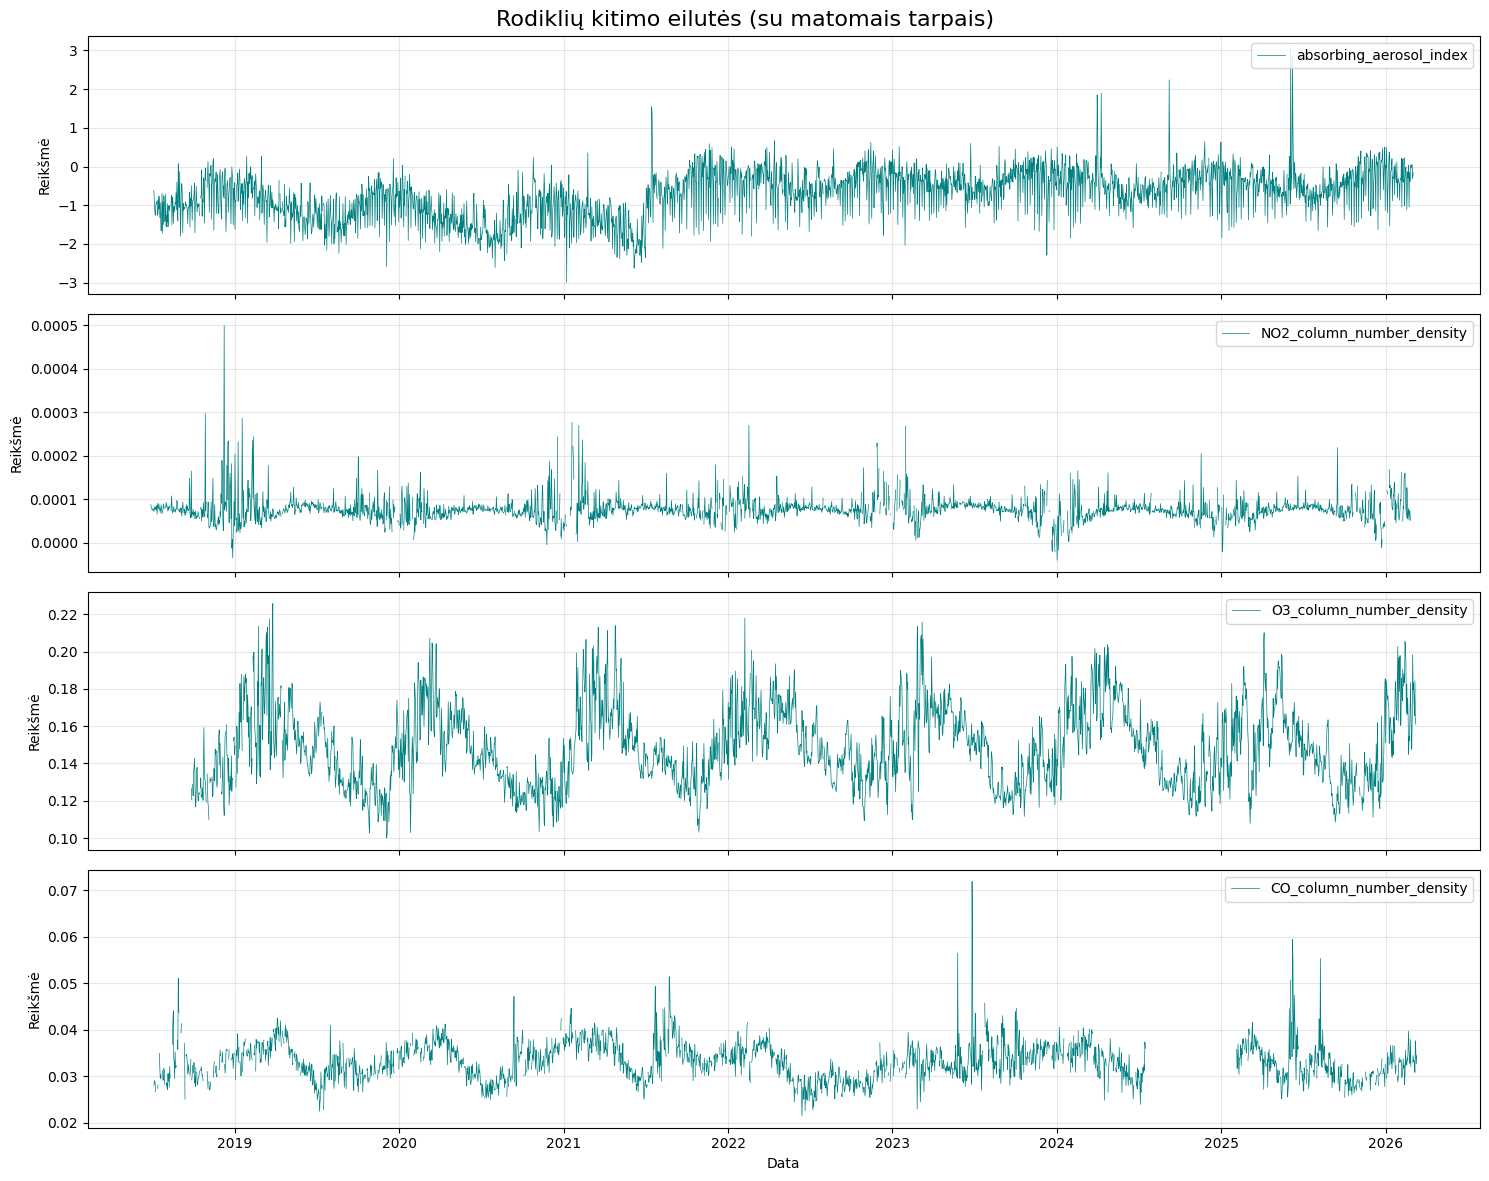

In [91]:
cols_to_show = ['absorbing_aerosol_index', 'NO2_column_number_density', 'O3_column_number_density', 'CO_column_number_density']

fig, axes = plt.subplots(len(cols_to_show), 1, figsize=(15, 12), sharex=True)

for i, col in enumerate(cols_to_show):
    axes[i].plot(sentinel_data.index, sentinel_data[col], label=col, color='teal', linewidth=0.5)
    axes[i].set_ylabel('Reikšmė')
    axes[i].legend(loc='upper right')
    axes[i].grid(True, alpha=0.3)

plt.xlabel('Data')
plt.suptitle('Rodiklių kitimo eilutės (su matomais tarpais)', fontsize=16)
plt.tight_layout()
plt.show()

In [104]:
missing_rows = sentinel_data[sentinel_data['absorbing_aerosol_index'].isnull()]
print(missing_rows[['absorbing_aerosol_index']])

                           absorbing_aerosol_index
time                                              
2018-06-27 21:00:00+00:00                      NaN
2018-06-28 21:00:00+00:00                      NaN
2018-06-29 21:00:00+00:00                      NaN
2018-06-30 21:00:00+00:00                      NaN
2018-07-01 21:00:00+00:00                      NaN
2018-07-02 21:00:00+00:00                      NaN
2018-08-10 21:00:00+00:00                      NaN
2018-10-14 21:00:00+00:00                      NaN
2018-10-29 22:00:00+00:00                      NaN
2019-04-09 21:00:00+00:00                      NaN
2019-04-14 21:00:00+00:00                      NaN
2019-07-14 21:00:00+00:00                      NaN
2020-01-14 22:00:00+00:00                      NaN
2020-08-25 21:00:00+00:00                      NaN
2020-09-13 21:00:00+00:00                      NaN
2020-10-20 21:00:00+00:00                      NaN
2021-07-27 21:00:00+00:00                      NaN
2021-12-10 22:00:00+00:00      

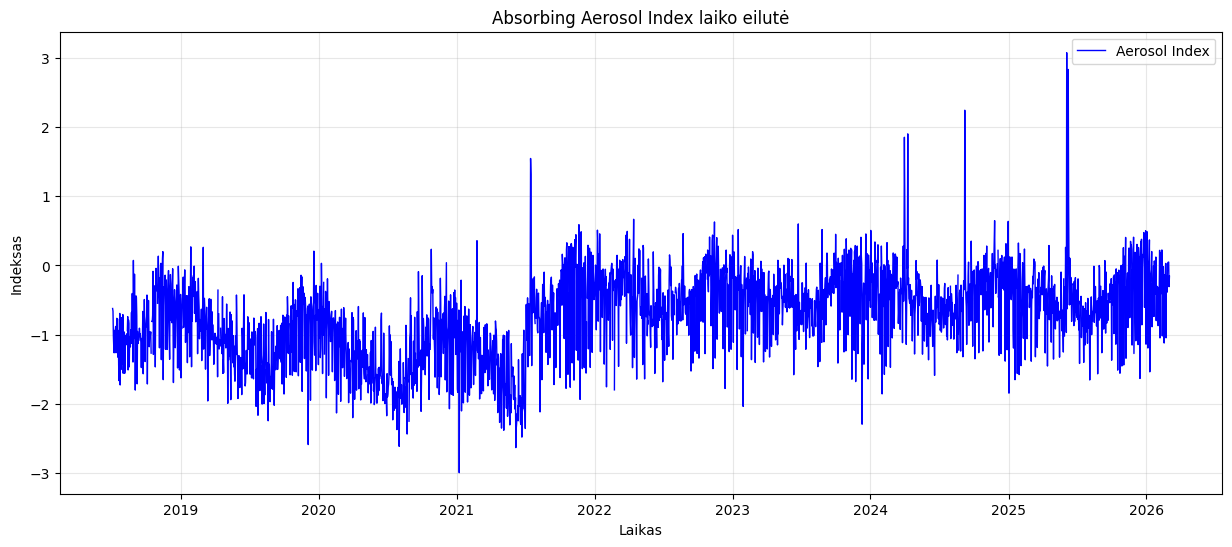

In [93]:
plt.figure(figsize=(15, 6))
plt.plot(sentinel_data.index, sentinel_data['absorbing_aerosol_index'], label='Aerosol Index', color='blue', linewidth=1)
plt.title('Absorbing Aerosol Index laiko eilutė')
plt.xlabel('Laikas')
plt.ylabel('Indeksas')
plt.grid(True, alpha=0.3)
plt.legend()

plt.show()

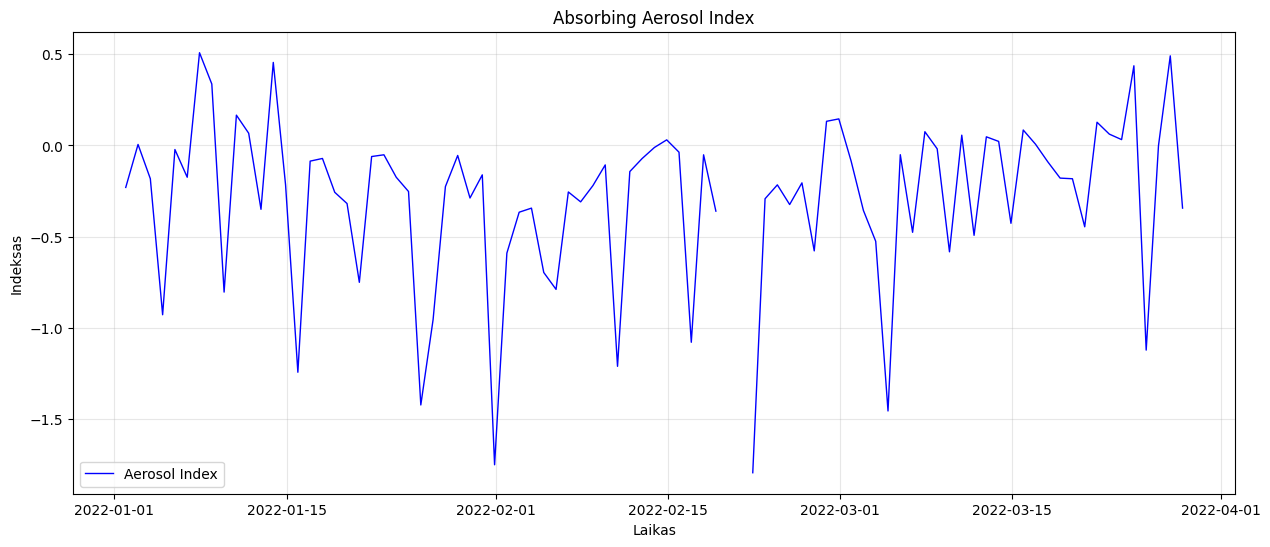

In [94]:
data_filtered = sentinel_data.loc['2022-01-01':'2022-03-28']

plt.figure(figsize=(15, 6))
plt.plot(data_filtered.index, data_filtered['absorbing_aerosol_index'], 
         label='Aerosol Index', color='blue', linewidth=1)
plt.title('Absorbing Aerosol Index')
plt.xlabel('Laikas')
plt.ylabel('Indeksas')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Praleistų reikšmių įrašymo būdai

In [95]:
sentinel_data = sentinel_data.drop(columns=['tropospheric_NO2_column_number_density'])

## MICE

https://medium.com/@kunalshrm175/multivariate-imputation-by-chained-equations-mice-2d3efb063434

In [96]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

In [98]:
mice_data = sentinel_data.copy()

imputer = IterativeImputer(random_state=0)
imputed_data = imputer.fit_transform(mice_data)

sentinel_imputed_mice = pd.DataFrame(
    imputed_data,
    columns=mice_data.columns,
    index=mice_data.index
)

c:\Users\rugil\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


In [99]:
print(sentinel_imputed_mice.isnull().sum())

absorbing_aerosol_index                    0
cloud_fraction                             0
cloud_top_pressure                         0
cloud_top_height                           0
cloud_base_pressure                        0
cloud_base_height                          0
cloud_optical_depth                        0
NO2_column_number_density                  0
stratospheric_NO2_column_number_density    0
NO2_slant_column_number_density            0
tropopause_pressure                        0
O3_column_number_density                   0
O3_effective_temperature                   0
CO_column_number_density                   0
H2O_column_number_density                  0
dtype: int64


In [100]:
print("\nStatistikos palyginimas (Aerosol Index):")
print("Prieš:", mice_data['absorbing_aerosol_index'].describe())
print("Po:", sentinel_imputed_mice['absorbing_aerosol_index'].describe())


Statistikos palyginimas (Aerosol Index):
Prieš: count    2777.000000
mean       -0.714192
std         0.613054
min        -2.990588
25%        -1.133140
50%        -0.649433
75%        -0.285962
max         3.069160
Name: absorbing_aerosol_index, dtype: float64
Po: count    2814.000000
mean       -0.713952
std         0.609194
min        -2.990588
25%        -1.123393
50%        -0.651617
75%        -0.288315
max         3.069160
Name: absorbing_aerosol_index, dtype: float64


In [101]:
def plot_variable(data_orig, data_imputed, variable, start_date=None, end_date=None):
    if start_date and end_date:
        orig_plot = data_orig.loc[start_date:end_date]
        imputed_plot = data_imputed.loc[start_date:end_date]
    else:
        orig_plot = data_orig
        imputed_plot = data_imputed

    plt.figure(figsize=(15, 7))

    plt.plot(imputed_plot.index, imputed_plot[variable],
             label='MICE Imputed', linestyle='--', alpha=0.7)

    plt.plot(orig_plot.index, orig_plot[variable],
             label='Original Data')

    plt.title(f'{variable}: Original vs Imputed')
    plt.xlabel('Laikas')
    plt.ylabel(variable)
    plt.grid(True, alpha=0.3)
    plt.legend()

    plt.tight_layout()
    plt.show()

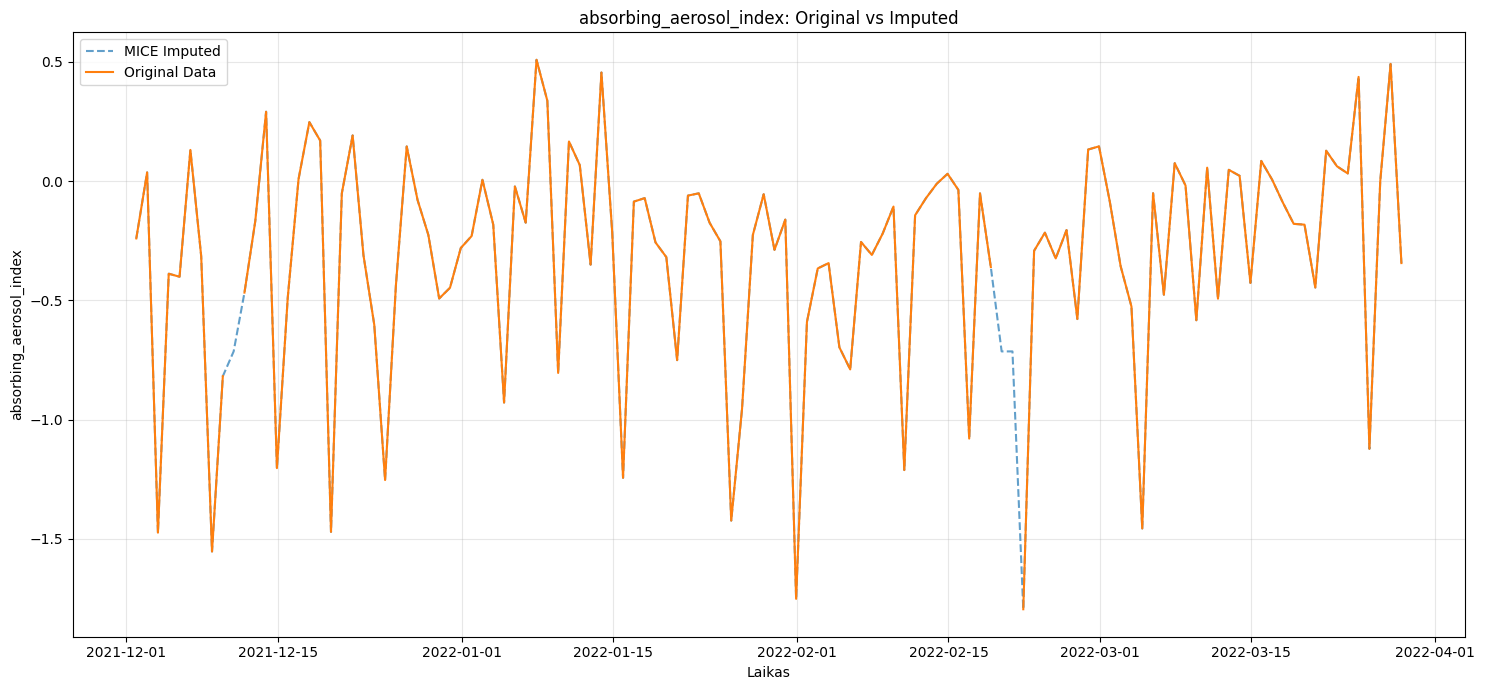

In [102]:
plot_variable(sentinel_data, sentinel_imputed_mice,
              variable='absorbing_aerosol_index',
              start_date='2021-12-01',
              end_date='2022-03-28')

In [105]:
missing_rows = sentinel_data[sentinel_data['O3_column_number_density'].isnull()]
print(missing_rows[['O3_column_number_density']])

                           O3_column_number_density
time                                               
2018-06-27 21:00:00+00:00                       NaN
2018-06-28 21:00:00+00:00                       NaN
2018-06-29 21:00:00+00:00                       NaN
2018-06-30 21:00:00+00:00                       NaN
2018-07-01 21:00:00+00:00                       NaN
...                                             ...
2025-11-02 22:00:00+00:00                       NaN
2025-11-05 22:00:00+00:00                       NaN
2025-11-07 22:00:00+00:00                       NaN
2026-03-09 22:00:00+00:00                       NaN
2026-03-10 22:00:00+00:00                       NaN

[121 rows x 1 columns]


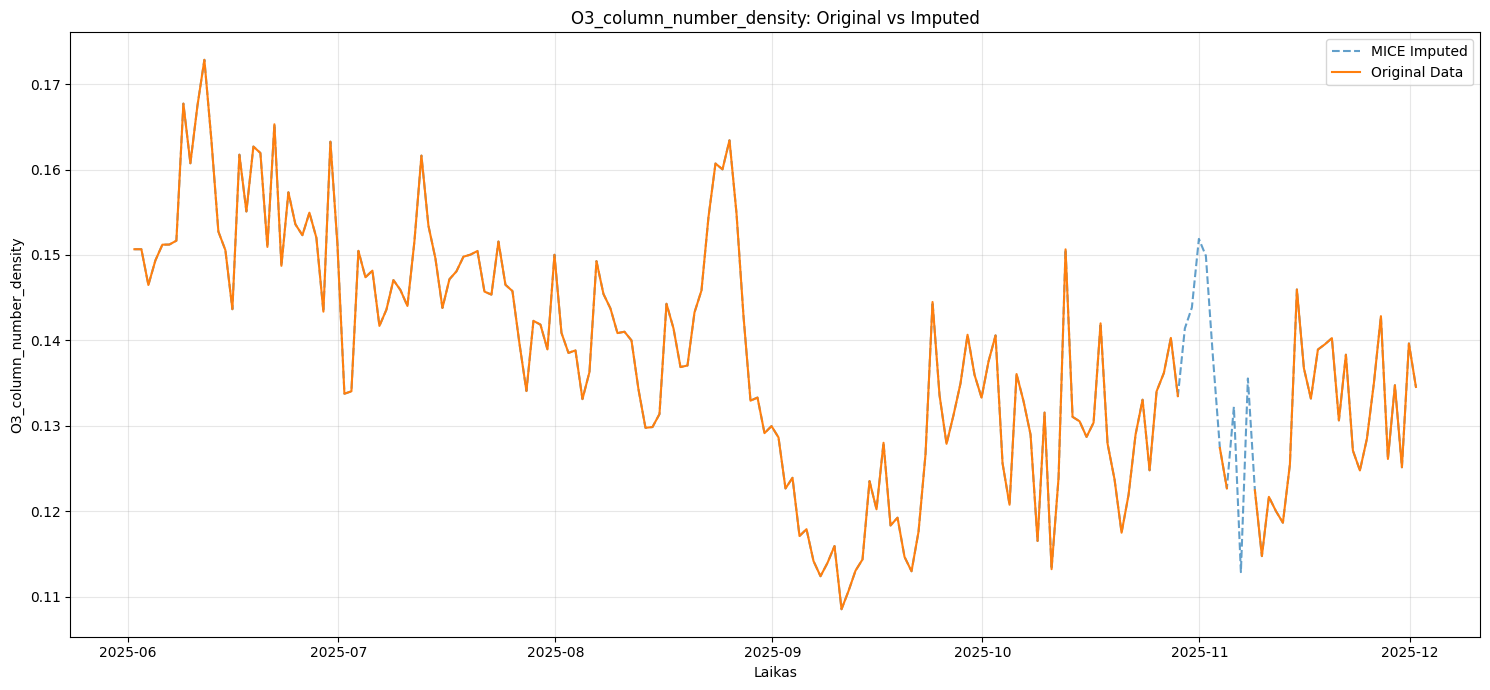

In [106]:
plot_variable(sentinel_data, sentinel_imputed_mice,
              variable='O3_column_number_density',
              start_date='2025-06-01',
              end_date='2025-12-01')

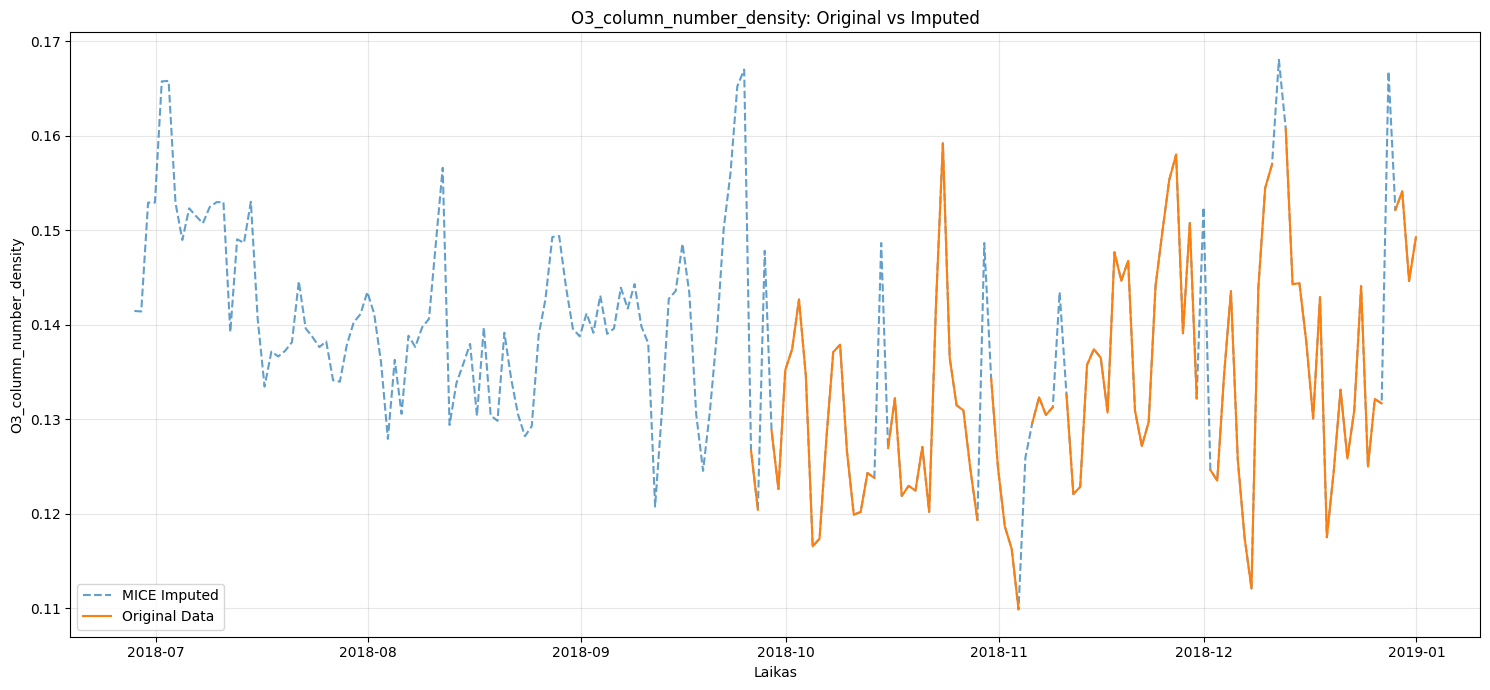

In [108]:
plot_variable(sentinel_data, sentinel_imputed_mice,
              variable='O3_column_number_density',
              start_date='2018-06-01',
              end_date='2018-12-31')

<span style="color:red">Šitie duomenys nuo 2018-09, todėl čia pradžioje nieko nebuvo, turbut reiks backcastint sita</span>

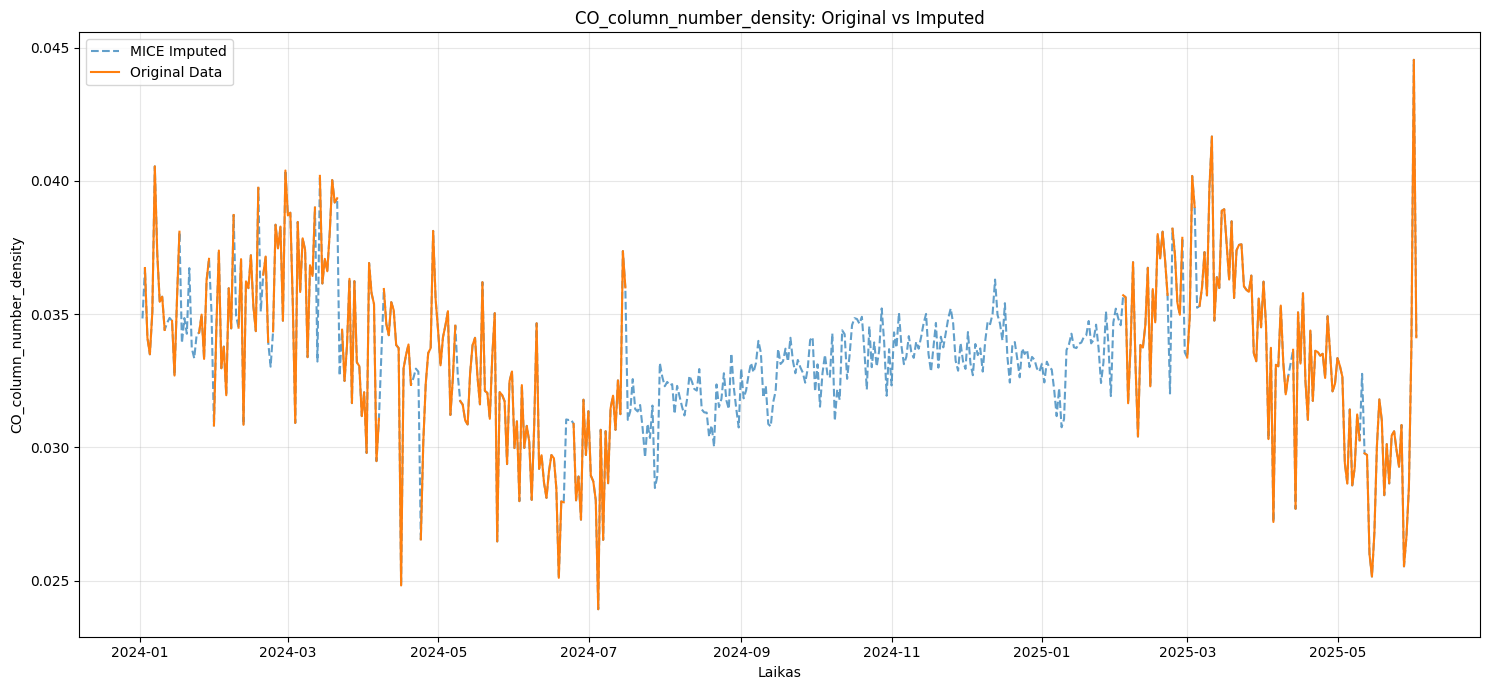

In [110]:
plot_variable(sentinel_data, sentinel_imputed_mice,
              variable='CO_column_number_density',
              start_date='2024-01-01',
              end_date='2025-06-01')

<span style="color:red">Nezinau ka reiks daryti su siuo milzinisku langu</span>